# GOLEM Fast Spectrometer to Fast Cameras Comparison

This notebook loads and visualizes fast spectrometry data alongside fast camera data from the GOLEM tokamak, allowing for temporal comparison of diagnostics.

**Features:**
- Load fast spectrometry signals (especially WHOLE spectrum)
- Load fast camera data (Radial and Vertical)
- Generate comparative plots showing temporal correlations
- Visual analysis of plasma behavior across diagnostics

## Setup & Configuration

In [29]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from golem_data_loader import GolemDataLoader, SpectroscopyLine

# Default shot number
DEFAULT_SHOT = 50377


# Color scheme for consistent visualization
COLORS = {
    'spectrum': '#2E86AB',      # Deep blue
    'camera_radial': '#A23B72', # Purple
    'camera_vertical': '#F18F01', # Orange
    'grid': '#CCCCCC'
}

# Figure styling
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})


## Section 1: Data Loading Functions

In [30]:
def load_all_data(shot_number: int) -> dict:
    """
    Load fast spectrometry and fast camera data from GOLEM server.
    
    Args:
        shot_number: The GOLEM shot number
        
    Returns:
        Dictionary containing loaded data with keys:
        - 'spectrum': Fast spectrometry data
        - 'cameras': Fast camera data
        - 'shot': Shot number
    """
    print(f"\n{'='*70}")
    print(f"LOADING DATA FOR SHOT {shot_number}")
    print(f"{'='*70}\n")
    
    loader = GolemDataLoader(shot_number=shot_number)
    data_container = {'shot': shot_number}
    
    # Load fast spectrometry (WHOLE spectrum only)
    print("► Loading Fast Spectrometry (WHOLE spectrum)...")
    try:
        spec_data = loader.load_fast_spectrometry(lines=[SpectroscopyLine.WHOLE])
        data_container['spectrum'] = spec_data['Whole']
        print(f"  ✓ Loaded {len(data_container['spectrum'].time)} spectral data points")
        print(f"    Time range: {data_container['spectrum'].time[0]:.4f}s - {data_container['spectrum'].time[-1]:.4f}s")
        print(f"    Intensity: {data_container['spectrum'].intensity.min():.2f} - {data_container['spectrum'].intensity.max():.2f} a.u.")
    except Exception as e:
        print(f"  ✗ Error loading spectrometry: {e}")
        data_container['spectrum'] = None
    
    # Load fast camera data
    print("\n► Loading Fast Camera Data (Radial & Vertical)...")
    try:
        cameras = loader.load_fast_cameras()
        data_container['cameras'] = cameras
        for cam_name, cam_data in cameras.items():
            print(f"  ✓ {cam_name.capitalize()}: {cam_data.frames.shape[0]} frames @ {cam_data.frame_rate:.0f} fps")
            print(f"    Duration: {cam_data.time[-1]*1000:.2f} ms")
    except Exception as e:
        print(f"  ✗ Error loading cameras: {e}")
        data_container['cameras'] = None
    
    print()
    return data_container

## Section 2: Spectrometry Visualization

In [31]:
def plot_spectrometry(data_container: dict) -> None:
    """
    Plot fast spectrometry WHOLE spectrum over time.
    
    Args:
        data_container: Dictionary containing loaded data
    """
    if data_container['spectrum'] is None:
        print("✗ No spectrometry data available")
        return
    
    print("► Generating Spectrometry Plot...")
    
    spectrum = data_container['spectrum']
    shot = data_container['shot']
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # Plot spectrum
    ax.plot(spectrum.time * 1e3, spectrum.intensity * 10, 
            linewidth=1.5, color=COLORS['spectrum'], label='WHOLE Spectrum')
    
    # Styling
    ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Intensity (a.u.)', fontsize=12, fontweight='bold')
    ax.set_title(f'Fast Spectrometry - WHOLE Spectrum | Shot {shot}', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--', color=COLORS['grid'])
    ax.legend(loc='upper right', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    print("  ✓ Spectrometry plot displayed\n")

## Section 3: Fast Cameras Visualization

In [32]:
def plot_fast_cameras(data_container: dict, max_frames: int = 400) -> None:
    """
    Plot fast camera data as temporal sequences.
    
    Args:
        data_container: Dictionary containing loaded data
        max_frames: Maximum number of frames to display
    """
    if data_container['cameras'] is None or not data_container['cameras']:
        print("✗ No camera data available")
        return
    
    print(f"► Generating Fast Camera Plots (max {max_frames} frames)...")
    
    cameras = data_container['cameras']
    shot = data_container['shot']
    
    # Create subplots for each camera
    fig, axes = plt.subplots(len(cameras), 1, figsize=(14, 4*len(cameras)))
    if len(cameras) == 1:
        axes = [axes]
    
    for ax, (cam_name, cam_data) in zip(axes, cameras.items()):
        # Limit frames for display
        n_frames = min(max_frames, cam_data.frames.shape[0])
        frames_subset = cam_data.frames[:n_frames]
        time_subset = cam_data.time[:n_frames] * 1e3
        
        # Reshape for display: (frames, height, width)
        if len(frames_subset.shape) == 3:
            display_data = frames_subset[:, :, 1]  # Use green channel only
        else:
            display_data = frames_subset
        
        # Transpose for proper visualization (time on x, spatial on y)
        im = ax.imshow(display_data.T, aspect='auto', cmap='gray', 
                       extent=[time_subset[0], time_subset[-1], 0, display_data.shape[1]],
                       interpolation='nearest', origin='lower')
        
        # Styling
        ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Spatial Position (pixels)', fontsize=12, fontweight='bold')
        ax.set_title(f'{cam_name.capitalize()} Fast Camera (80k fps) | Shot {shot}', 
                    fontsize=13, fontweight='bold')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, label='Intensity (a.u.)')
    
    plt.tight_layout()
    plt.show()
    print(f"  ✓ Fast camera plots displayed\n")

## Section 4: Combined Comparison

## Section 5: Camera Temporal Averaging

In [33]:
def plot_camera_temporal_average(data_container: dict) -> None:
    """
    Plot per-frame pixel-averaged camera intensity over time.
    Averages all pixel values in each frame to create a temporal signal.
    
    Args:
        data_container: Dictionary containing loaded data
    """
    if data_container['cameras'] is None or not data_container['cameras']:
        print("✗ No camera data available")
        return
    
    print("► Generating Camera Temporal Average Plots...")
    
    cameras = data_container['cameras']
    shot = data_container['shot']
    
    fig, axes = plt.subplots(len(cameras), 1, figsize=(14, 4*len(cameras)))
    if len(cameras) == 1:
        axes = [axes]
    
    for ax, (cam_name, cam_data) in zip(axes, cameras.items()):
        # Get frames and average all pixels in each frame
        frames = cam_data.frames
        
        # Handle RGB channels if present
        if len(frames.shape) == 3:
            display_data = frames[:, :, 1]  # Use green channel only
        else:
            display_data = frames
        
        # Apply ROI for vertical camera before averaging
        if cam_name == 'vertical':
            if display_data.ndim == 2:
                display_data = display_data[:, 301:561]
            elif display_data.ndim == 3:
                display_data = display_data[:, 301:561, :]
        
        # Average over all spatial dimensions per frame (all pixels averaged for each frame)
        # This creates a single value per frame
        temporal_average = np.mean(display_data, axis=tuple(range(1, display_data.ndim)))
        time_ms = cam_data.time * 1e3
        
        # Plot
        ax.plot(time_ms, temporal_average, linewidth=1.5, color=COLORS['camera_radial'], 
                label=f'{cam_name.capitalize()} - Pixel Average')
        
        # Styling
        ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Pixel-Averaged Intensity (a.u.)', fontsize=12, fontweight='bold')
        ax.set_title(f'{cam_name.capitalize()} Camera - Per-Frame Pixel Average | Shot {shot}', 
                    fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='upper right', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    print("  ✓ Camera temporal average plots displayed\n")

In [34]:
def plot_whole_lcs_crs_comparison(data_container: dict) -> None:
    """
    Plot normalized (0-1) raw vs corrected temporal signals for:
    1) WHOLE spectrometry (corrected by LCS*CRS)
    2) Fast cameras (corrected by LCG*CRG)

    The correction factors are read from globals using suffixes like 46, 68, 1012, etc.,
    where each suffix represents a 2 ms bin (start-end in ms).
    """
    if data_container.get('spectrum') is None:
        print("✗ No spectrometry data available")
        return

    print("► Generating normalized raw vs corrected comparisons (WHOLE + cameras)...")

    spectrum = data_container['spectrum']
    cameras = data_container.get('cameras') or {}
    shot = data_container['shot']

    def normalize_signal(signal: np.ndarray) -> np.ndarray:
        min_val = np.min(signal)
        max_val = np.max(signal)
        span = max_val - min_val
        if span <= 0:
            return np.zeros_like(signal)
        return (signal - min_val) / span

    def suffix_to_bin(suffix: str) -> tuple:
        if len(suffix) == 2:
            start_ms = int(suffix[0])
            end_ms = int(suffix[1])
        elif len(suffix) == 3:
            start_ms = int(suffix[0])
            end_ms = int(suffix[1:])
        else:
            start_ms = int(suffix[:-2])
            end_ms = int(suffix[-2:])
        return start_ms, end_ms

    def build_factor_map(prefix: str) -> dict:
        factor_map = {}
        for key, value in globals().items():
            if not isinstance(key, str) or not key.startswith(prefix):
                continue
            suffix = key[len(prefix):]
            if not suffix.isdigit():
                continue
            try:
                start_ms, end_ms = suffix_to_bin(suffix)
                factor_map[(start_ms, end_ms)] = float(value)
            except Exception:
                continue
        return factor_map

    def build_time_factors(time_ms: np.ndarray, factor_map: dict) -> np.ndarray:
        factors = np.ones_like(time_ms, dtype=float)
        time_bin_ms = 2.0
        bin_start = np.floor(time_ms / time_bin_ms) * time_bin_ms
        bin_end = bin_start + time_bin_ms
        for (start_ms, end_ms), value in factor_map.items():
            mask = (bin_start == start_ms) & (bin_end == end_ms)
            if np.any(mask):
                factors[mask] = value
        return factors

    # WHOLE: raw vs corrected (normalized only)
    time_ms = spectrum.time * 1e3
    whole_raw = spectrum.intensity
    lcs_map = build_factor_map("LCS")
    crs_map = build_factor_map("CRS")
    lcs_factors = build_time_factors(time_ms, lcs_map)
    crs_factors = build_time_factors(time_ms, crs_map)
    whole_corrected = whole_raw * lcs_factors * crs_factors
    whole_norm_raw = normalize_signal(whole_raw)
    whole_norm_corrected = normalize_signal(whole_corrected)

    print(f"  LCS values found: {len(lcs_map)}")
    print(f"  CRS values found: {len(crs_map)}")
    print(f"  WHOLE max normalized abs diff: {np.max(np.abs(whole_norm_raw - whole_norm_corrected)):.6f}")

    # Cameras: raw vs corrected (normalized only)
    lcg_map = build_factor_map("LCG")
    crg_map = build_factor_map("CRG")
    print(f"  LCG values found: {len(lcg_map)}")
    print(f"  CRG values found: {len(crg_map)}")

    camera_series = []
    for cam_name, cam_data in cameras.items():
        frames = cam_data.frames
        if len(frames.shape) == 3:
            display_data = frames[:, :, 1]  # Use green channel only
        else:
            display_data = frames

        if cam_name == 'vertical':
            if display_data.ndim == 2:
                display_data = display_data[:, 301:561]
            elif display_data.ndim == 3:
                display_data = display_data[:, 301:561, :]

        pixel_avg = np.mean(display_data, axis=tuple(range(1, display_data.ndim)))
        cam_time_ms = cam_data.time * 1e3

        lcg_factors = build_time_factors(cam_time_ms, lcg_map)
        crg_factors = build_time_factors(cam_time_ms, crg_map)
        camera_corrected = pixel_avg * lcg_factors * crg_factors

        camera_series.append({
            'name': cam_name.capitalize(),
            'time_ms': cam_time_ms,
            'raw_norm': normalize_signal(pixel_avg),
            'corr_norm': normalize_signal(camera_corrected),
        })

    n_panels = 1 + len(camera_series)
    fig, axes = plt.subplots(n_panels, 1, figsize=(14, 3.8*n_panels))
    if n_panels == 1:
        axes = [axes]

    # WHOLE panel
    axes[0].plot(time_ms, whole_norm_raw, linewidth=1.8, linestyle='--', color=COLORS['spectrum'], alpha=0.95,
                 label='WHOLE raw (normalized 0-1)')
    axes[0].plot(time_ms, whole_norm_corrected, linewidth=1.8, linestyle='-', color=COLORS['camera_radial'], alpha=0.95,
                 label='WHOLE corrected (normalized 0-1)')
    axes[0].set_ylabel('Normalized Intensity (0-1)', fontsize=11, fontweight='bold')
    axes[0].set_title('WHOLE: Raw vs Corrected', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3, linestyle='--')
    axes[0].legend(loc='upper right', fontsize=9)

    # Camera panels
    for panel_idx, series in enumerate(camera_series, start=1):
        cam_color = COLORS['camera_vertical'] if series['name'].lower() == 'vertical' else COLORS['camera_radial']
        axes[panel_idx].plot(series['time_ms'], series['raw_norm'], linewidth=1.8, linestyle='--', color=COLORS['spectrum'], alpha=0.95,
                             label=f"{series['name']} raw (normalized 0-1)")
        axes[panel_idx].plot(series['time_ms'], series['corr_norm'], linewidth=1.8, linestyle='-', color=cam_color, alpha=0.95,
                             label=f"{series['name']} corrected (normalized 0-1)")
        axes[panel_idx].set_ylabel('Normalized Intensity (0-1)', fontsize=11, fontweight='bold')
        axes[panel_idx].set_title(f"{series['name']} Camera: Raw vs Corrected", fontsize=12, fontweight='bold')
        axes[panel_idx].grid(True, alpha=0.3, linestyle='--')
        axes[panel_idx].legend(loc='upper right', fontsize=9)

    axes[-1].set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
    fig.suptitle(f'GOLEM Normalized Raw vs Corrected Comparison | Shot {shot}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("  ✓ Normalized raw vs corrected comparison displayed\n")

def plot_comparison(data_container: dict) -> None:
    """
    Create a single unified plot showing all three diagnostic signals on one axis.
    Applies time offset correction to align spectrometry with camera start time.
    Camera signals are corrected by LCG*CRG before normalization.

    Args:
        data_container: Dictionary containing loaded data
    """
    if data_container['spectrum'] is None or data_container['cameras'] is None:
        print("✗ Incomplete data for comparison (need both spectrum and cameras)")
        return

    print("► Generating Comparison Plot...")

    spectrum = data_container['spectrum']
    cameras = data_container['cameras']
    shot = data_container['shot']

    camera_ref_time = next(iter(cameras.values())).time[0]
    spec_start_time = spectrum.time[0]
    time_offset = spec_start_time - camera_ref_time

    print("\n  TIME DIAGNOSTICS (BEFORE CORRECTION):")
    print(f"  Spectrometry: t_start={spectrum.time[0]*1e3:.4f} ms")
    for cam_name, cam_data in cameras.items():
        print(f"  {cam_name.capitalize()}: t_start={cam_data.time[0]*1e3:.4f} ms")

    print(f"\n  TIME OFFSET: {time_offset*1e3:.4f} ms ({time_offset*1e6:.2f} µs)")

    spectrum_time_corrected = spectrum.time - time_offset

    print(f"\n  TIME DIAGNOSTICS (AFTER CORRECTION):")
    print(f"  Spectrometry: t_start={spectrum_time_corrected[0]*1e3:.4f} ms, t_end={spectrum_time_corrected[-1]*1e3:.4f} ms")
    for cam_name, cam_data in cameras.items():
        print(f"  {cam_name.capitalize()}: t_start={cam_data.time[0]*1e3:.4f} ms, t_end={cam_data.time[-1]*1e3:.4f} ms")

    time_min = spectrum_time_corrected.min()
    time_max = spectrum_time_corrected.max()
    for cam_data in cameras.values():
        time_min = max(time_min, cam_data.time.min())
        time_max = min(time_max, cam_data.time.max())

    print(f"\n  Common time range: {time_min*1e3:.2f} - {time_max*1e3:.2f} ms")

    common_time = np.linspace(time_min, time_max, len(spectrum.time))
    common_time_ms = common_time * 1e3

    def normalize_signal(signal: np.ndarray) -> np.ndarray:
        min_val = np.min(signal)
        max_val = np.max(signal)
        span = max_val - min_val
        if span <= 0:
            return np.zeros_like(signal)
        return (signal - min_val) / span

    def suffix_to_bin(suffix: str) -> tuple:
        if len(suffix) == 2:
            start_ms = int(suffix[0])
            end_ms = int(suffix[1])
        elif len(suffix) == 3:
            start_ms = int(suffix[0])
            end_ms = int(suffix[1:])
        else:
            start_ms = int(suffix[:-2])
            end_ms = int(suffix[-2:])
        return start_ms, end_ms

    def build_factor_map(prefix: str) -> dict:
        factor_map = {}
        for key, value in globals().items():
            if not isinstance(key, str) or not key.startswith(prefix):
                continue
            suffix = key[len(prefix):]
            if not suffix.isdigit():
                continue
            try:
                start_ms, end_ms = suffix_to_bin(suffix)
                factor_map[(start_ms, end_ms)] = float(value)
            except Exception:
                continue
        return factor_map

    lcs_map = build_factor_map("LCS")
    crs_map = build_factor_map("CRS")
    lcg_map = build_factor_map("LCG")
    crg_map = build_factor_map("CRG")
    time_bin_ms = 2.0
    bin_start = np.floor(common_time_ms / time_bin_ms) * time_bin_ms
    bin_end = bin_start + time_bin_ms
    lcs_factors = np.ones_like(common_time, dtype=float)
    crs_factors = np.ones_like(common_time, dtype=float)
    lcg_factors = np.ones_like(common_time, dtype=float)
    crg_factors = np.ones_like(common_time, dtype=float)

    for (start_ms, end_ms), value in lcs_map.items():
        mask = (bin_start == start_ms) & (bin_end == end_ms)
        if np.any(mask):
            lcs_factors[mask] = value

    for (start_ms, end_ms), value in crs_map.items():
        mask = (bin_start == start_ms) & (bin_end == end_ms)
        if np.any(mask):
            crs_factors[mask] = value

    for (start_ms, end_ms), value in lcg_map.items():
        mask = (bin_start == start_ms) & (bin_end == end_ms)
        if np.any(mask):
            lcg_factors[mask] = value

    for (start_ms, end_ms), value in crg_map.items():
        mask = (bin_start == start_ms) & (bin_end == end_ms)
        if np.any(mask):
            crg_factors[mask] = value

    print(f"  LCS values found: {len(lcs_map)}")
    print(f"  CRS values found: {len(crs_map)}")
    print(f"  LCG values found: {len(lcg_map)}")
    print(f"  CRG values found: {len(crg_map)}")

    fig, ax = plt.subplots(figsize=(14, 6))

    spectrum_interp = np.interp(common_time, spectrum_time_corrected, spectrum.intensity)
    spectrum_weighted = spectrum_interp * lcs_factors * crs_factors
    spectrum_normalized = normalize_signal(spectrum_weighted)
    ax.plot(common_time_ms, spectrum_normalized,
            linewidth=2, color=COLORS['spectrum'], label='WHOLE Spectrum', alpha=0.8)

    for idx, (cam_name, cam_data) in enumerate(cameras.items()):
        frames = cam_data.frames
        if len(frames.shape) == 3:
            display_data = frames[:, :, 1]
        else:
            display_data = frames

        if cam_name == 'vertical':
            if display_data.ndim == 2:
                display_data = display_data[:, 301:561]
            elif display_data.ndim == 3:
                display_data = display_data[:, 301:561, :]

        pixel_avg = np.mean(display_data, axis=tuple(range(1, display_data.ndim)))
        camera_interp = np.interp(common_time, cam_data.time, pixel_avg)
        camera_weighted = camera_interp * lcg_factors * crg_factors
        camera_normalized = normalize_signal(camera_weighted)

        color = COLORS['camera_vertical'] if idx > 0 else COLORS['camera_radial']
        ax.plot(common_time_ms, camera_normalized, linewidth=2,
                color=color, label=f'{cam_name.capitalize()} - Pixel Avg', alpha=0.8)

    ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Intensity (0-1)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=11)

    plt.title(f'GOLEM Multi-Diagnostic Temporal Comparison | Shot {shot} (Time-Corrected, Normalized)',
              fontsize=14, fontweight='bold', pad=15)
    fig.tight_layout()
    plt.show()
    print("\n  ✓ Comparison plot displayed\n")

In [35]:
# ============================================================================
# CONFIGURE SHOT NUMBER HERE
# ============================================================================
SHOT_TO_ANALYZE = 51176 






  # ← CHANGE THIS VALUE TO ANALYZE A DIFFERENT SHOT

## Section 6: Mini Spectrometer Data Loading and Visualization

In [36]:
def load_mini_spectrometer(shot_number: int) -> dict:
    """
    Load mini spectrometer HDF5 data from GOLEM server.
    
    Args:
        shot_number: The GOLEM shot number
        
    Returns:
        Dictionary containing mini spectrometer spectral data
    """
    print(f"\n{'='*70}")
    print(f"LOADING MINI SPECTROMETER DATA FOR SHOT {shot_number}")
    print(f"{'='*70}\n")
    
    loader = GolemDataLoader(shot_number=shot_number)
    mini_spec_data = {}
    
    try:
        # Load plasma timing first
        plasma_timing = loader.load_plasma_timing()
        
        # Load mini spectrometer data from HDF5
        print("► Loading Mini Spectrometer HDF5 Data...")
        mini_data = loader.load_minispectrometer_h5(h5_filename="IRVISUV_0.h5", apply_sensitivity_correction=False)
        
        if mini_data is not None:
            # Fix dimension mismatch: wavelengths array is shorter (first element skipped in loader)
            # Trim spectra to match wavelengths array
            if mini_data.spectra.shape[1] != len(mini_data.wavelengths):
                mini_data.spectra = mini_data.spectra[:, :len(mini_data.wavelengths)]
            
            mini_spec_data['data'] = mini_data
            mini_spec_data['plasma_start_ms'] = plasma_timing.t_plasma_start_ms
            mini_spec_data['plasma_end_ms'] = plasma_timing.t_plasma_end_ms
            
            print(f"  ✓ Mini spectrometer data loaded successfully")
            print(f"  Spectral data shape: {mini_data.spectra.shape} (time samples x wavelengths)")
            print(f"  Wavelength range: {mini_data.wavelengths[0]:.2f} - {mini_data.wavelengths[-1]:.2f} nm")
            print(f"  Intensity range: {mini_data.spectra.min():.2f} - {mini_data.spectra.max():.2f} a.u.")
            print(f"  Plasma timing: {plasma_timing.t_plasma_start_ms:.2f} - {plasma_timing.t_plasma_end_ms:.2f} ms")
        else:
            print("  ✗ No mini spectrometer data available for this shot")
            
    except Exception as e:
        print(f"  ✗ Error loading mini spectrometer: {e}")
        import traceback
        traceback.print_exc()
        mini_spec_data['data'] = None
    
    mini_spec_data['shot'] = shot_number
    return mini_spec_data

In [37]:
def plot_mini_spectrometer_segments(mini_spec_data: dict) -> None:
    """
    Plot all mini spectrometer time segments: noise, signal (avg-control subtracted), 
    control spectrum, and control average.
    """
    if mini_spec_data.get('data') is None:
        print("✗ No mini spectrometer data available to plot")
        return
    
    mini_data = mini_spec_data['data']
    shot = mini_spec_data['shot']
    
    if not hasattr(mini_data, 'spectra') or not hasattr(mini_data, 'wavelengths'):
        print("✗ Invalid mini spectrometer data structure")
        return
    
    spectra = mini_data.spectra  # Shape: (n_time_samples, n_wavelengths)
    wavelengths = mini_data.wavelengths
    n_time_samples = spectra.shape[0]
    
    # Fixed time bin: 2.0 ms per sample (0-2, 2-4, 4-6, etc.)
    time_bin_ms = 2.0
    
    print(f"► Analyzing {n_time_samples} Mini Spectrometer Samples...")
    print(f"  Spectra shape: {spectra.shape}")
    print(f"  Wavelengths: {len(wavelengths)} points from {wavelengths[0]:.1f} to {wavelengths[-1]:.1f} nm")
    print(f"  Time bin size: {time_bin_ms:.1f} ms per sample")
    
    # Detect signal vs noise using line-based thresholds (before control subtraction)
    he_line_nm = 587.56
    h_line_nm = 656.6
    he_threshold = 9000.0
    h_threshold = 4000.0
    window = 3  # +-3 wavelength bins around the line
    
    he_idx = int(np.argmin(np.abs(wavelengths - he_line_nm)))
    h_idx = int(np.argmin(np.abs(wavelengths - h_line_nm)))
    
    he_start = max(0, he_idx - window)
    he_end = min(len(wavelengths), he_idx + window + 1)
    h_start = max(0, h_idx - window)
    h_end = min(len(wavelengths), h_idx + window + 1)
    
    is_signal = np.zeros(n_time_samples, dtype=bool)
    he_signal = np.zeros(n_time_samples, dtype=bool)
    h_signal = np.zeros(n_time_samples, dtype=bool)
    for i in range(n_time_samples):
        he_slice = spectra[i, he_start:he_end]
        if np.any(he_slice > he_threshold):
            is_signal[i] = True
            he_signal[i] = True
            continue
        h_slice = spectra[i, h_start:h_end]
        if np.any(h_slice > h_threshold):
            is_signal[i] = True
            h_signal[i] = True
    
    signal_indices = np.where(is_signal)[0]
    noise_indices = np.where(~is_signal)[0]
    
    gas_label = "He" if np.any(he_signal) else "H" if np.any(h_signal) else "None"
    
    print(f"\n  SIGNAL DETECTION:")
    print(f"  Signal samples: {list(signal_indices)} ({len(signal_indices)} samples)")
    print(f"  Noise samples: {list(noise_indices)} ({len(noise_indices)} samples)")
    print(f"  Gas label: {gas_label}")
    
    # Check if signal is continuous
    if len(signal_indices) > 0:
        signal_gaps = np.diff(signal_indices)
        if np.any(signal_gaps > 1):
            print(f"\n✗ ERROR: Failed to detect continuous signal!")
            print(f"  Signal appears at non-continuous indices: {list(signal_indices)}")
            print(f"  Gaps detected: {signal_gaps[signal_gaps > 1]}")
            return
        
        signal_start = signal_indices[0]
        signal_end = signal_indices[-1]
        print(f"  ✓ Continuous signal detected from sample {signal_start} to {signal_end}")
    else:
        print(f"\n✗ ERROR: No signal samples detected!")
        return
    
    # Create control sample: average all noise EXCEPT those adjacent to signal
    noise_before_signal = signal_start - 1 if signal_start > 0 else None
    noise_after_signal = signal_end + 1 if signal_end < n_time_samples - 1 else None
    
    control_noise_indices = []
    for idx in noise_indices:
        if idx != noise_before_signal and idx != noise_after_signal:
            control_noise_indices.append(idx)
    
    if len(control_noise_indices) == 0:
        print(f"\n✗ ERROR: No noise samples available for control (all adjacent to signal)")
        return
    
    print(f"\n  CONTROL SAMPLE CREATION:")
    print(f"  Excluded noise indices: {[i for i in [noise_before_signal, noise_after_signal] if i is not None]}")
    print(f"  Control noise indices: {control_noise_indices}")
    
    # Create control spectrum and control average
    control_spectrum = np.mean(spectra[control_noise_indices, :], axis=0)
    control_average = np.mean(control_spectrum)  # Single scalar value
    
    print(f"  Control spectrum average: {control_average:.2f}")
    
    # Subtract control average from signal samples
    signal_subtracted = []
    for idx in signal_indices:
        subtracted = spectra[idx, :] - control_average
        subtracted = np.maximum(subtracted, 0)  # Clip negative values to 0
        signal_subtracted.append(subtracted)
    
    print("\n  SIGNAL TOTAL INTENSITY (AFTER CONTROL SUBTRACTION):")
    signal_total_intensities = {}
    signal_total_intensities_band = {}
    signal_total_intensities_band_adjusted = {}
    signal_total_intensities_green = {}
    signal_total_intensities_green_adjusted = {}
    signal_ratio = {}
    signal_ratio_band_adjusted = {}
    signal_ratio_green = {}
    signal_ratio_green_adjusted = {}
    band_mask = (wavelengths >= 350.0) & (wavelengths <= 1100.0)
    green_mask = (wavelengths >= 401.9) & (wavelengths <= 615.9)
    spec_resp_data = np.loadtxt('mini wawelenghts fast spec responsivity.txt', skiprows=5)
    if spec_resp_data.ndim == 1:
        spec_resp_data = spec_resp_data.reshape(1, -1)
    if spec_resp_data.shape[1] >= 3:
        spec_resp_wavelengths = spec_resp_data[:, 1]
        spec_resp_values = spec_resp_data[:, 2]
    else:
        spec_resp_wavelengths = spec_resp_data[:, 0]
        spec_resp_values = spec_resp_data[:, 1]
    spec_weights = np.interp(wavelengths, spec_resp_wavelengths, spec_resp_values, left=0.0, right=0.0)
    green_resp_data = np.loadtxt('mini_fast_spec_green_responsivity.csv', delimiter=',', skiprows=1)
    green_resp_wavelengths = green_resp_data[:, 0]
    green_resp_values = green_resp_data[:, 1]
    green_weights = np.interp(wavelengths, green_resp_wavelengths, green_resp_values, left=0.0, right=0.0)
    ICBGt1t2 = float(np.sum([np.sum(s[green_mask]) for s in signal_subtracted]))
    globals()['ICBGt1t2'] = ICBGt1t2
    print(f"  Signal integrated green band (401.9-615.9 nm): {ICBGt1t2:.2f} -> ICBGt1t2")
    ICAGt1t2 = float(np.sum([np.sum(s[green_mask] * green_weights[green_mask]) for s in signal_subtracted]))
    globals()['ICAGt1t2'] = ICAGt1t2
    print(f"  Signal adjusted green band (401.9-615.9 nm, weighted): {ICAGt1t2:.2f} -> ICAGt1t2")
    ICASt1t2 = float(np.sum([np.sum(s[band_mask] * spec_weights[band_mask]) for s in signal_subtracted]))
    globals()['ICASt1t2'] = ICASt1t2
    print(f"  Signal adjusted spectrometer band (350-1100 nm, weighted): {ICASt1t2:.2f} -> ICASt1t2")
    for idx, sig_idx in enumerate(signal_indices):
        total_intensity = float(np.sum(signal_subtracted[idx]))  # IWB: Intensity Whole Before (entire spectrum)
        band_intensity = float(np.sum(signal_subtracted[idx][band_mask]))  # ICBS: Intensity Cut Before Spectrometer (350-1100 nm)
        adjusted_band_intensity = float(np.sum(signal_subtracted[idx][band_mask] * spec_weights[band_mask]))  # ICAS: ICBS weighted by mini spectrometer responsivity
        green_intensity = float(np.sum(signal_subtracted[idx][green_mask]))  # ICBG: Intensity Cut Before Green (401.9-615.9 nm)
        adjusted_green_intensity = float(np.sum(signal_subtracted[idx][green_mask] * green_weights[green_mask]))  # ICAG: ICBG weighted by green responsivity
        t_start_ms = sig_idx * time_bin_ms
        t_end_ms = (sig_idx + 1) * time_bin_ms
        name = f"IWB{int(t_start_ms)}{int(t_end_ms)}"
        band_name = f"ICBS{int(t_start_ms)}{int(t_end_ms)}"
        adjusted_band_name = f"ICAS{int(t_start_ms)}{int(t_end_ms)}"
        green_name = f"ICBG{int(t_start_ms)}{int(t_end_ms)}"
        adjusted_green_name = f"ICAG{int(t_start_ms)}{int(t_end_ms)}"
        ratio_name = f"CRS{int(t_start_ms)}{int(t_end_ms)}"  # CRS: Cut Ratio Spectrometer (IWB / ICBS)
        ratio_band_adjusted_name = f"LCS{int(t_start_ms)}{int(t_end_ms)}"  # LCS: ICBS / ICAS
        ratio_green_name = f"CRG{int(t_start_ms)}{int(t_end_ms)}"  # CRG: Cut Ratio Green (IWB / ICBG)
        ratio_green_adjusted_name = f"LCG{int(t_start_ms)}{int(t_end_ms)}"  # LCG: ICBG / ICAG
        signal_total_intensities[name] = total_intensity
        signal_total_intensities_band[band_name] = band_intensity
        signal_total_intensities_band_adjusted[adjusted_band_name] = adjusted_band_intensity
        signal_total_intensities_green[green_name] = green_intensity
        signal_total_intensities_green_adjusted[adjusted_green_name] = adjusted_green_intensity
        crs = total_intensity / band_intensity if band_intensity > 0 else 0.0
        lcs = band_intensity / adjusted_band_intensity if adjusted_band_intensity > 0 else 0.0
        crg = total_intensity / green_intensity if green_intensity > 0 else 0.0
        lcg = green_intensity / adjusted_green_intensity if adjusted_green_intensity > 0 else 0.0
        signal_ratio[ratio_name] = crs
        signal_ratio_band_adjusted[ratio_band_adjusted_name] = lcs
        signal_ratio_green[ratio_green_name] = crg
        signal_ratio_green_adjusted[ratio_green_adjusted_name] = lcg
        globals()[name] = total_intensity
        globals()[band_name] = band_intensity
        globals()[adjusted_band_name] = adjusted_band_intensity
        globals()[green_name] = green_intensity
        globals()[adjusted_green_name] = adjusted_green_intensity
        globals()[ratio_name] = crs
        globals()[ratio_band_adjusted_name] = lcs
        globals()[ratio_green_name] = crg
        globals()[ratio_green_adjusted_name] = lcg
        print(f"  Sample {sig_idx}: {total_intensity:.2f} -> {name}")
        print(f"  Sample {sig_idx}: {band_intensity:.2f} -> {band_name}")
        print(f"  Sample {sig_idx}: {adjusted_band_intensity:.2f} -> {adjusted_band_name}")
        print(f"  Sample {sig_idx}: {green_intensity:.2f} -> {green_name}")
        print(f"  Sample {sig_idx}: {adjusted_green_intensity:.2f} -> {adjusted_green_name}")
        print(f"  Sample {sig_idx}: {crs:.4f} -> {ratio_name}")
        print(f"  Sample {sig_idx}: {lcs:.4f} -> {ratio_band_adjusted_name}")
        print(f"  Sample {sig_idx}: {crg:.4f} -> {ratio_green_name}")
        print(f"  Sample {sig_idx}: {lcg:.4f} -> {ratio_green_adjusted_name}")
    
    # Create plot: ALL samples (noise + signal + control + control avg)
    n_plots = n_time_samples + 2  # all samples + control spectrum + control average
    n_cols = 4
    n_rows = int(np.ceil(n_plots / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes_flat = axes.flatten()
    
    # Plot all time samples
    plot_idx = 0
    for time_idx in range(n_time_samples):
        ax = axes_flat[plot_idx]
        
        # Calculate time range (0.0-2.0, 2.0-4.0, etc.)
        t_start_ms = time_idx * time_bin_ms
        t_end_ms = (time_idx + 1) * time_bin_ms
        
        # Determine sample type and get appropriate spectrum
        if time_idx in signal_indices:
            # Signal: use avg-control subtracted version
            sig_array_idx = np.where(signal_indices == time_idx)[0][0]
            spectrum = signal_subtracted[sig_array_idx]
            color = '#FF5555'
            alpha = 0.8
            label = 'SIGNAL'
        else:
            # Noise: use original
            spectrum = spectra[time_idx, :]
            color = '#999999'
            alpha = 0.4
            label = 'noise'
        
        ax.plot(wavelengths, spectrum, linewidth=1.5, color=color, alpha=alpha)
        ax.fill_between(wavelengths, spectrum, alpha=0.3*alpha, color=color)
        ax.set_xlabel('Wavelength (nm)', fontsize=10, fontweight='bold')
        ax.set_ylabel('Intensity [a.u.]', fontsize=10, fontweight='bold')
        ax.set_title(f'{t_start_ms:.1f}-{t_end_ms:.1f} ms\n({label})', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlim(wavelengths[0], wavelengths[-1])
        plot_idx += 1
    
    # Plot control spectrum
    ax_control = axes_flat[plot_idx]
    ax_control.plot(wavelengths, control_spectrum, linewidth=1.5, color='#0066CC', alpha=0.8)
    ax_control.fill_between(wavelengths, control_spectrum, alpha=0.3, color='#0066CC')
    ax_control.set_xlabel('Wavelength (nm)', fontsize=10, fontweight='bold')
    ax_control.set_ylabel('Intensity [a.u.]', fontsize=10, fontweight='bold')
    ax_control.set_title(f'Control Spectrum\n(avg of {len(control_noise_indices)} noise)', 
                        fontsize=11, fontweight='bold')
    ax_control.grid(True, alpha=0.3, linestyle='--')
    ax_control.set_xlim(wavelengths[0], wavelengths[-1])
    plot_idx += 1
    
    # Plot control average as horizontal line
    ax_avg = axes_flat[plot_idx]
    ax_avg.axhline(y=control_average, linewidth=2, color='#00CC66', alpha=0.8)
    ax_avg.fill_between(wavelengths, 0, control_average, alpha=0.3, color='#00CC66')
    ax_avg.set_xlabel('Wavelength (nm)', fontsize=10, fontweight='bold')
    ax_avg.set_ylabel('Intensity [a.u.]', fontsize=10, fontweight='bold')
    ax_avg.set_title(f'Control Average\n({control_average:.2f})', 
                    fontsize=11, fontweight='bold')
    ax_avg.grid(True, alpha=0.3, linestyle='--')
    ax_avg.set_xlim(wavelengths[0], wavelengths[-1])
    plot_idx += 1
    
    # Hide unused subplots
    for idx in range(plot_idx, len(axes_flat)):
        axes_flat[idx].set_visible(False)
    
    fig.suptitle(f'Mini Spec - All Samples | Shot {shot} | {gas_label}', 
                fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    print(f"\n  ✓ {n_time_samples} sample plots + control spectrum + control average displayed\n")

2026-02-28 19:14:14,708 - golem_data_loader.golem_data_loader - INFO - Successfully loaded plasma start time from http://golem.fjfi.cvut.cz/shots/51176/Diagnostics/PlasmaDetection/Results/t_plasma_start
2026-02-28 19:14:14,746 - golem_data_loader.golem_data_loader - INFO - Successfully loaded plasma end time from http://golem.fjfi.cvut.cz/shots/51176/Diagnostics/PlasmaDetection/Results/t_plasma_end
2026-02-28 19:14:14,747 - golem_data_loader.golem_data_loader - INFO - Loaded plasma timing: 3.77 - 27.55 ms
2026-02-28 19:14:14,770 - golem_data_loader.golem_data_loader - INFO - Successfully loaded plasma start time from http://golem.fjfi.cvut.cz/shots/51176/Diagnostics/PlasmaDetection/Results/t_plasma_start
2026-02-28 19:14:14,786 - golem_data_loader.golem_data_loader - INFO - Successfully loaded plasma end time from http://golem.fjfi.cvut.cz/shots/51176/Diagnostics/PlasmaDetection/Results/t_plasma_end
2026-02-28 19:14:14,787 - golem_data_loader.golem_data_loader - INFO - Loaded plasma ti


Loading mini spectrometer data...

LOADING MINI SPECTROMETER DATA FOR SHOT 51176

► Loading Mini Spectrometer HDF5 Data...


2026-02-28 19:14:14,904 - golem_data_loader.golem_data_loader - INFO - Loaded spectra: shape=(20, 2048), wavelengths: shape=(2047,)
2026-02-28 19:14:14,907 - golem_data_loader.golem_data_loader - WARNING - Mini-spectrometer data has mismatched lengths: spectra=2048, wavelengths=2047; trimming to 2047 columns
2026-02-28 19:14:14,911 - golem_data_loader.golem_data_loader - INFO - Cleaned up temporary file: C:\Users\stepa\AppData\Local\Temp\tmpbdw3brw5.h5


  ✓ Mini spectrometer data loaded successfully
  Spectral data shape: (20, 2047) (time samples x wavelengths)
  Wavelength range: 188.11 - 1108.53 nm
  Intensity range: 604.00 - 7297.00 a.u.
  Plasma timing: 3.77 - 27.55 ms
► Analyzing 20 Mini Spectrometer Samples...
  Spectra shape: (20, 2047)
  Wavelengths: 2047 points from 188.1 to 1108.5 nm
  Time bin size: 2.0 ms per sample

  SIGNAL DETECTION:
  Signal samples: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)] (11 samples)
  Noise samples: [np.int64(0), np.int64(1), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)] (9 samples)
  Gas label: H
  ✓ Continuous signal detected from sample 2 to 12

  CONTROL SAMPLE CREATION:
  Excluded noise indices: [np.int64(1), np.int64(13)]
  Control noise indices: [np.int64(0), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64

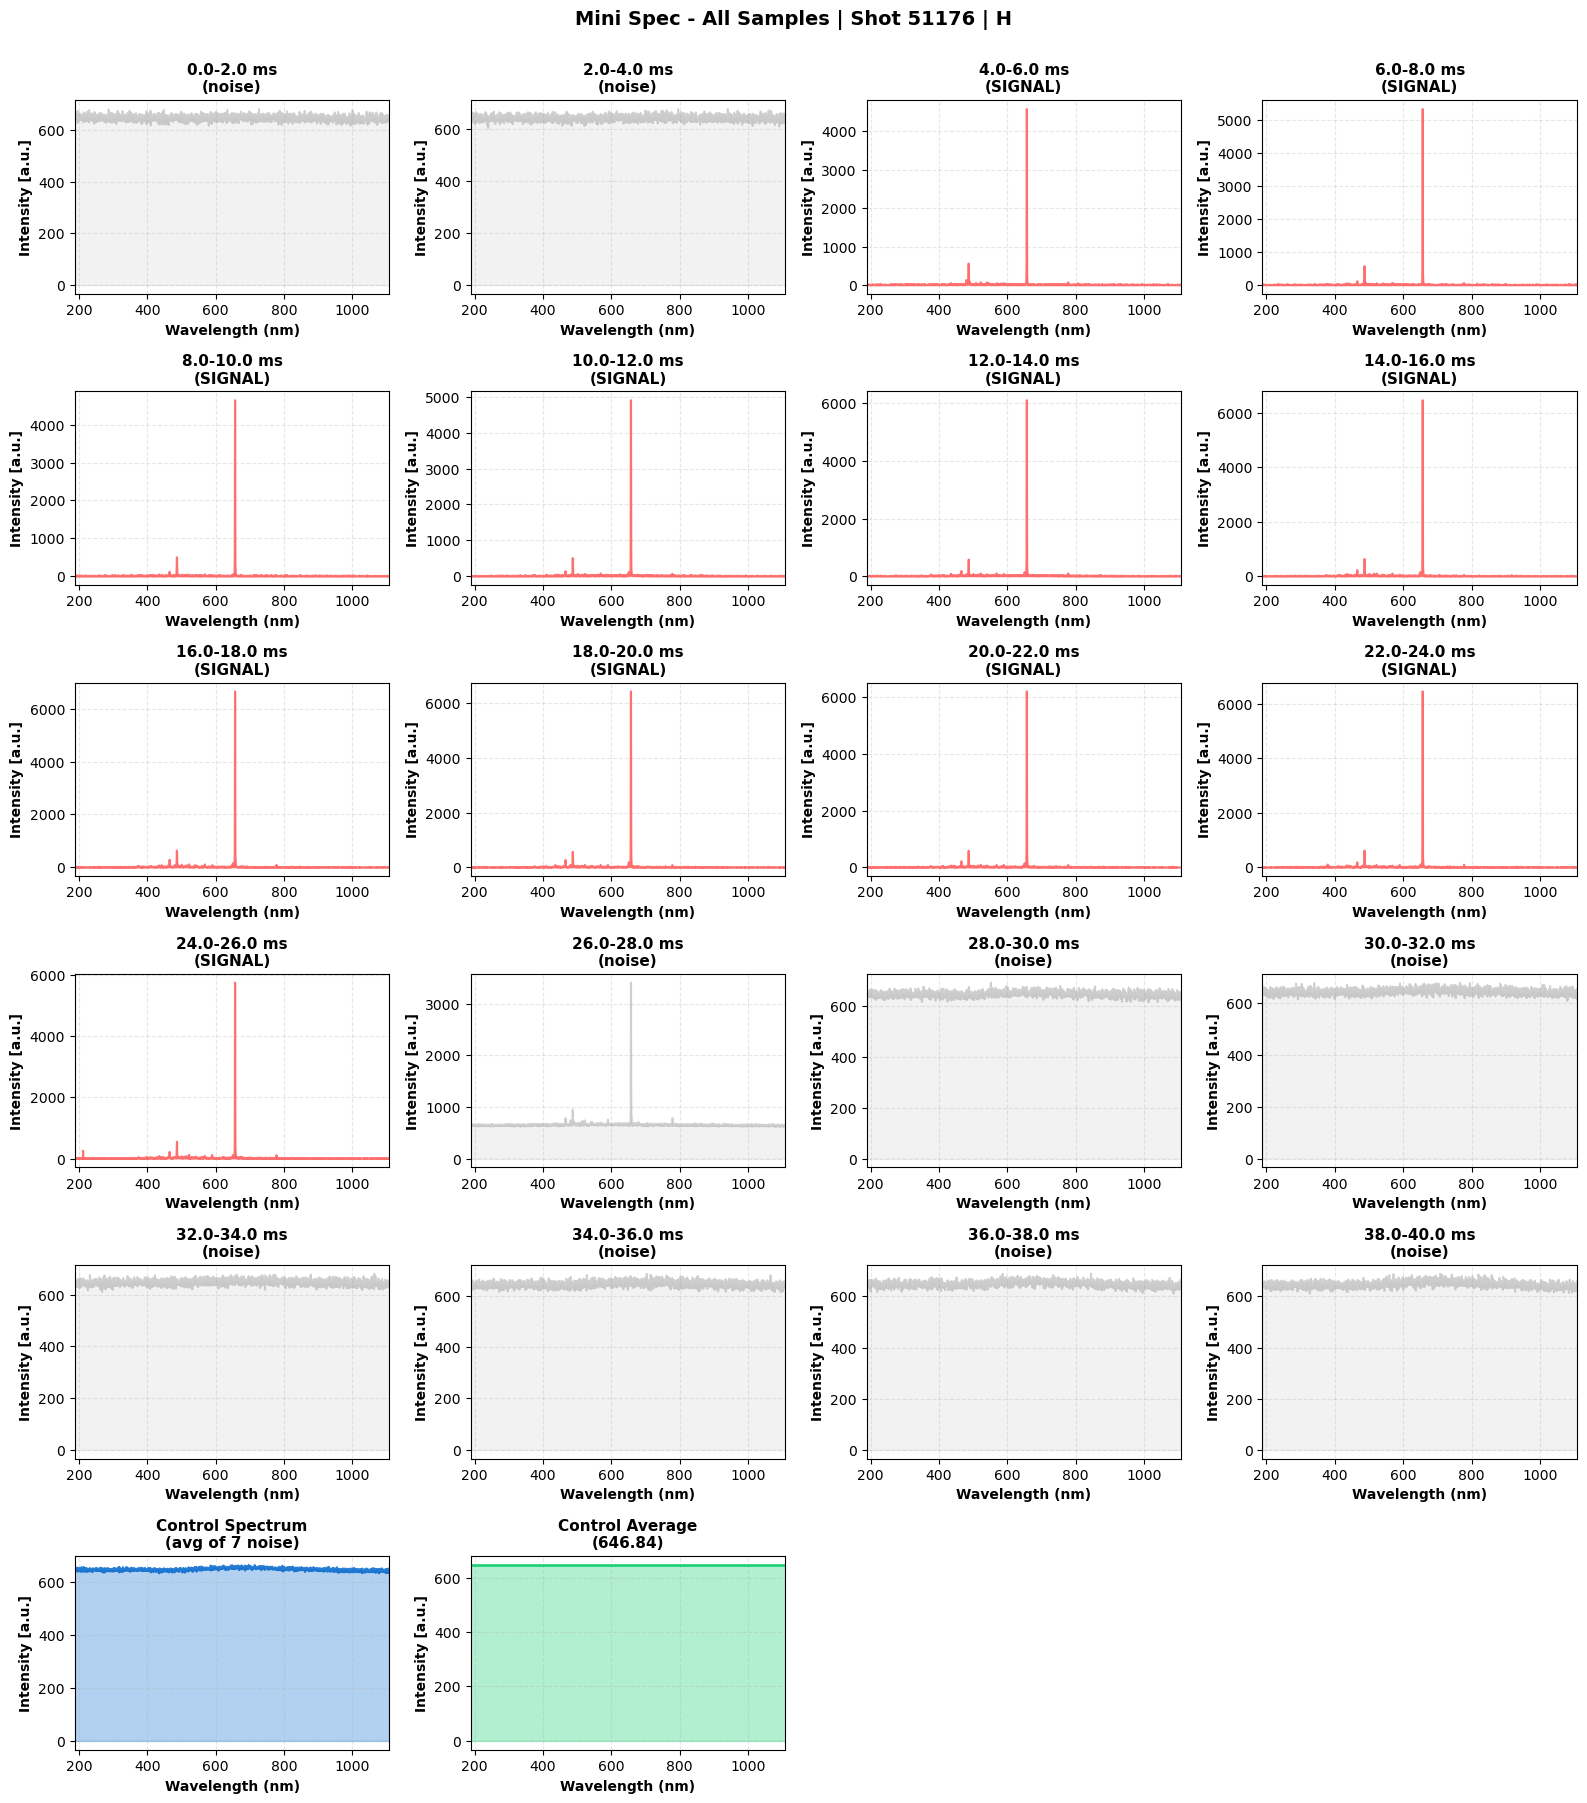


  ✓ 20 sample plots + control spectrum + control average displayed



In [38]:
# Load and plot mini spectrometer data
print("\nLoading mini spectrometer data...")
mini_spec_data = load_mini_spectrometer(SHOT_TO_ANALYZE)
plot_mini_spectrometer_segments(mini_spec_data)

2026-02-28 19:14:17,308 - golem_data_loader.golem_data_loader - INFO - Successfully loaded plasma start time from http://golem.fjfi.cvut.cz/shots/51176/Diagnostics/PlasmaDetection/Results/t_plasma_start



RUNNING ANALYSIS FOR SHOT 51176


LOADING DATA FOR SHOT 51176



2026-02-28 19:14:17,498 - golem_data_loader.golem_data_loader - INFO - Successfully loaded plasma end time from http://golem.fjfi.cvut.cz/shots/51176/Diagnostics/PlasmaDetection/Results/t_plasma_end
2026-02-28 19:14:17,500 - golem_data_loader.golem_data_loader - INFO - Loaded plasma timing: 3.77 - 27.55 ms
2026-02-28 19:14:17,612 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Whole spectrometry from http://golem.fjfi.cvut.cz/shots/51176/Diagnostics/FastSpectrometry/DAS_raw_data_dir/ch6.csv
2026-02-28 19:14:17,621 - golem_data_loader.golem_data_loader - INFO - Whole: loaded 3999 rows, columns = ['    0', '-0.000']
2026-02-28 19:14:17,655 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame rate from http://golem.fjfi.cvut.cz/shots/51176/Diagnostics/FastCameras/Parameters/recrate_ux100a
2026-02-28 19:14:17,656 - golem_data_loader.golem_data_loader - INFO - Fast Camera (Radial) frame rate: 40000.0 fps
2026-02-28 19:14:17,657 - g

► Loading Fast Spectrometry (WHOLE spectrum)...
  ✓ Loaded 3999 spectral data points
    Time range: 0.0000s - 0.0400s
    Intensity: 0.00 - 0.12 a.u.

► Loading Fast Camera Data (Radial & Vertical)...


2026-02-28 19:14:17,716 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 1 from http://golem.fjfi.cvut.cz/shots/51176/Diagnostics/FastCameras/Camera_Radial/Frames/1.png
2026-02-28 19:14:17,819 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 2 from http://golem.fjfi.cvut.cz/shots/51176/Diagnostics/FastCameras/Camera_Radial/Frames/2.png
2026-02-28 19:14:17,909 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 3 from http://golem.fjfi.cvut.cz/shots/51176/Diagnostics/FastCameras/Camera_Radial/Frames/3.png
2026-02-28 19:14:18,011 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 4 from http://golem.fjfi.cvut.cz/shots/51176/Diagnostics/FastCameras/Camera_Radial/Frames/4.png
2026-02-28 19:14:18,064 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 5 from http://golem.fjfi.c

  ✓ Radial: 1599 frames @ 40000 fps
    Duration: 39.95 ms
  ✓ Vertical: 1599 frames @ 40000 fps
    Duration: 39.95 ms


► Plot 1/2: Raw vs Responsivity-Corrected (WHOLE + Cameras)
► Generating normalized raw vs corrected comparisons (WHOLE + cameras)...
  LCS values found: 11
  CRS values found: 11
  WHOLE max normalized abs diff: 0.512195
  LCG values found: 11
  CRG values found: 11


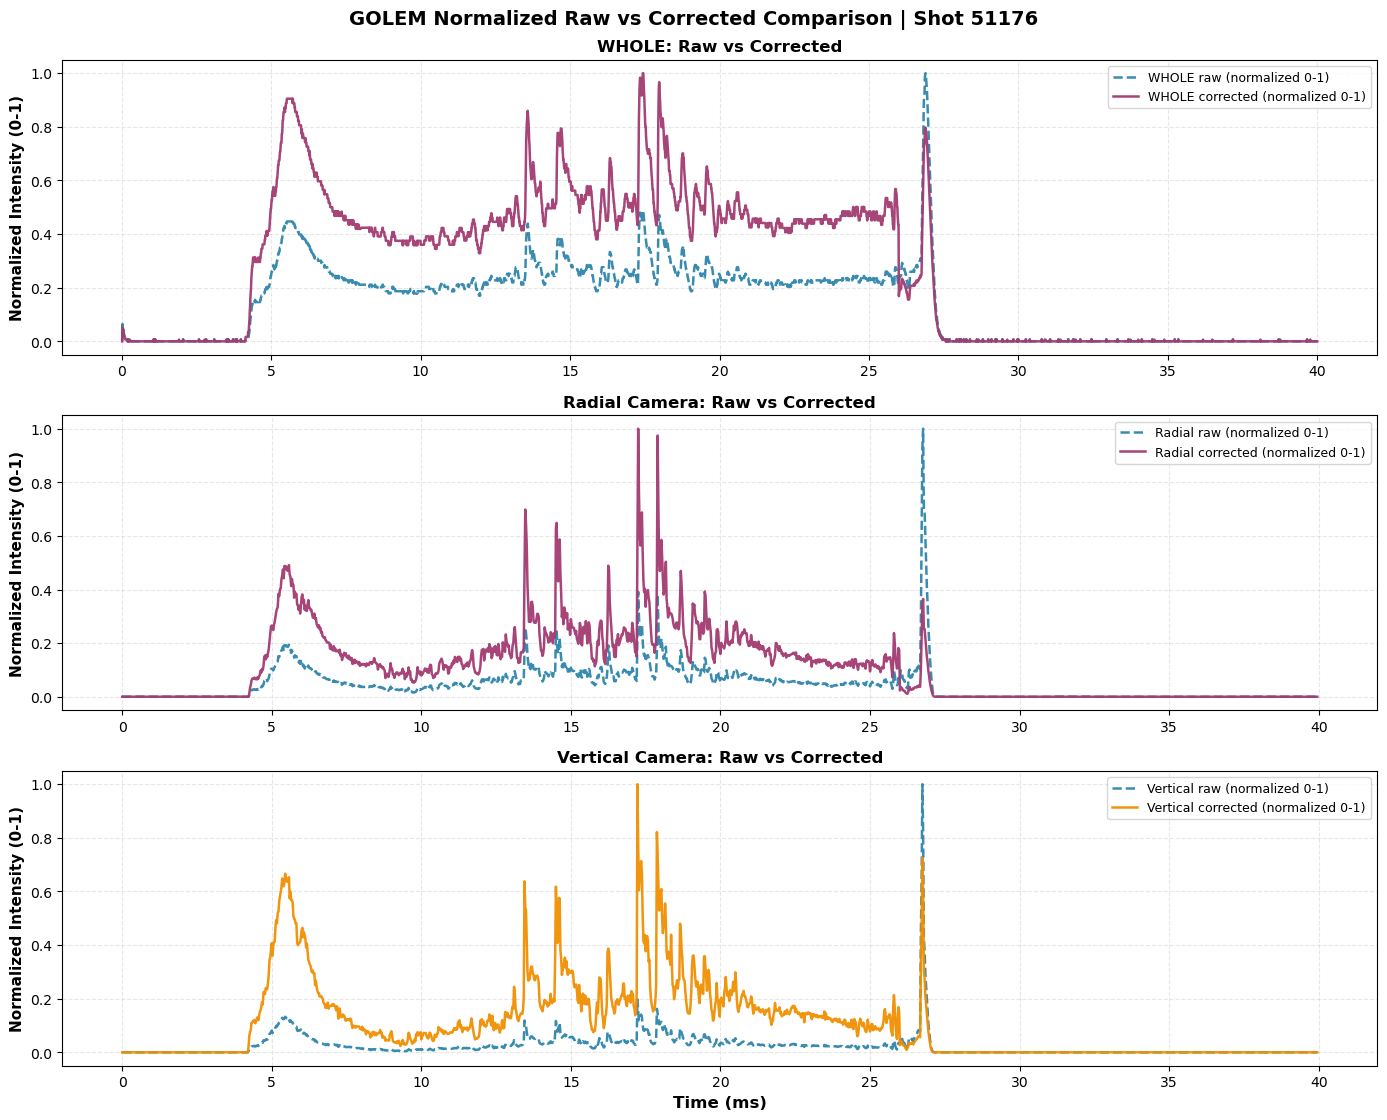

  ✓ Normalized raw vs corrected comparison displayed


► Plot 2/2: Unified Temporal Comparison (Corrected + Normalized)
► Generating Comparison Plot...

  TIME DIAGNOSTICS (BEFORE CORRECTION):
  Spectrometry: t_start=0.0100 ms
  Radial: t_start=0.0000 ms
  Vertical: t_start=0.0000 ms

  TIME OFFSET: 0.0100 ms (10.00 µs)

  TIME DIAGNOSTICS (AFTER CORRECTION):
  Spectrometry: t_start=0.0000 ms, t_end=39.9900 ms
  Radial: t_start=0.0000 ms, t_end=39.9500 ms
  Vertical: t_start=0.0000 ms, t_end=39.9500 ms

  Common time range: 0.00 - 39.95 ms
  LCS values found: 11
  CRS values found: 11
  LCG values found: 11
  CRG values found: 11


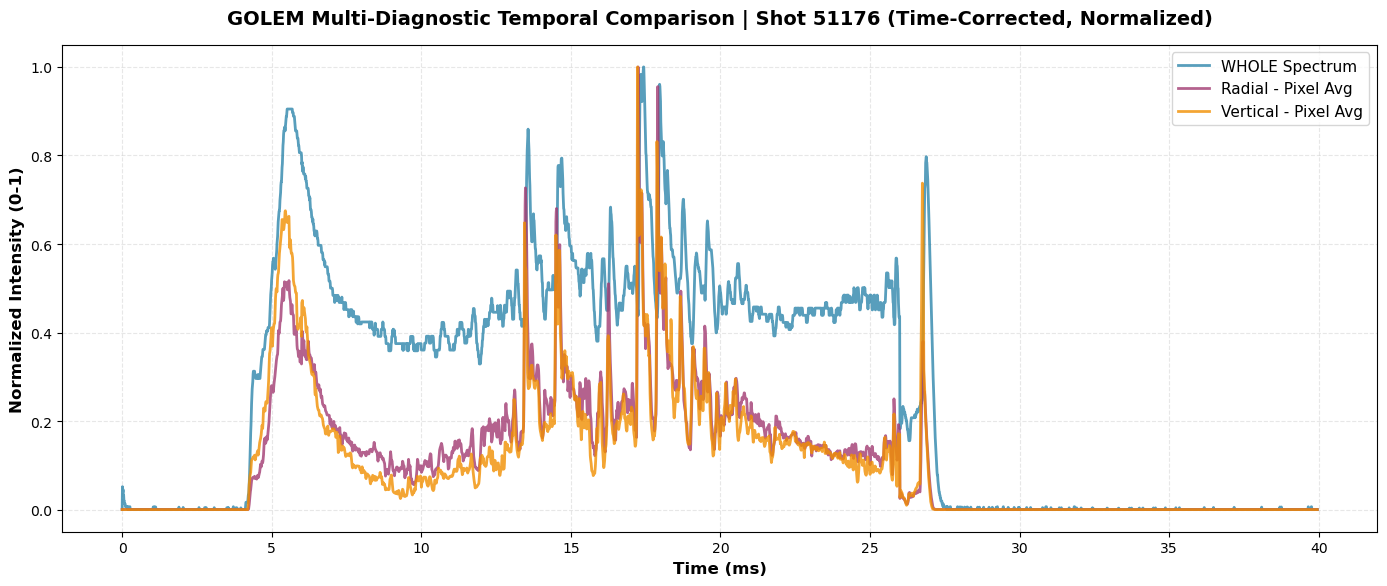


  ✓ Comparison plot displayed

ANALYSIS COMPLETE



In [39]:
# Load data and generate comparison plots
print(f"\n{'='*70}")
print(f"RUNNING ANALYSIS FOR SHOT {SHOT_TO_ANALYZE}")
print(f"{'='*70}\n")

data = load_all_data(SHOT_TO_ANALYZE)

print("\n► Plot 1/2: Raw vs Responsivity-Corrected (WHOLE + Cameras)")
plot_whole_lcs_crs_comparison(data)

print("\n► Plot 2/2: Unified Temporal Comparison (Corrected + Normalized)")
plot_comparison(data)

print(f"{'='*70}")
print("ANALYSIS COMPLETE")
print(f"{'='*70}\n")

► Generating normalized raw vs corrected comparisons (WHOLE + cameras)...
  LCS values found: 11
  CRS values found: 11
  WHOLE max normalized abs diff: 0.512195
  LCG values found: 11
  CRG values found: 11


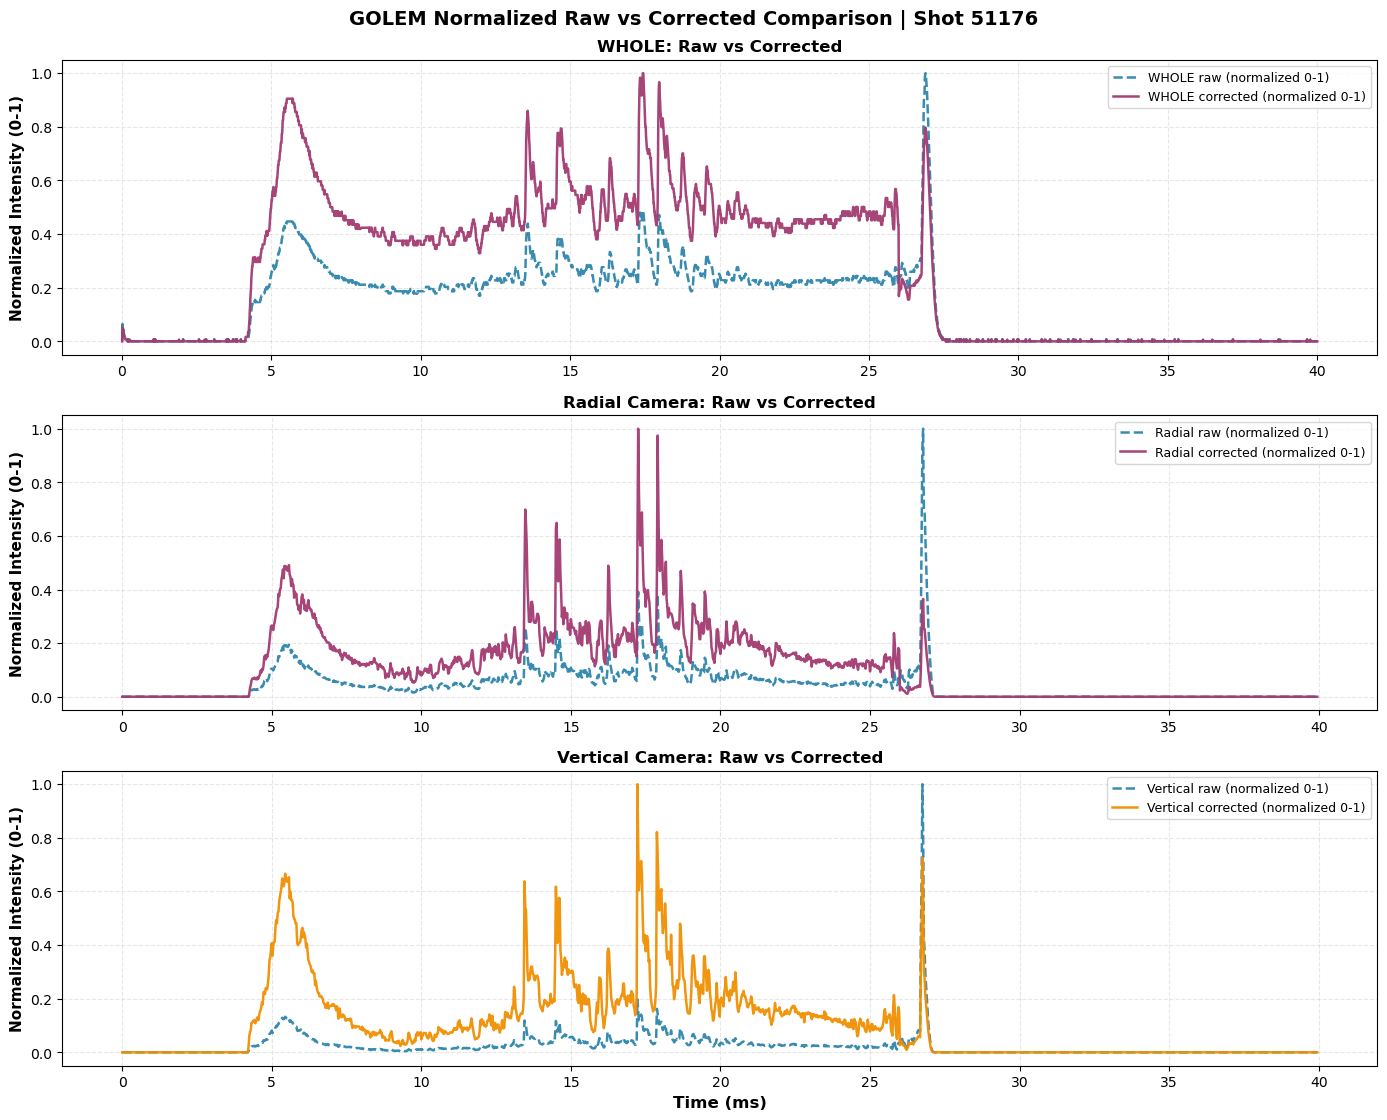

  ✓ Normalized raw vs corrected comparison displayed



In [40]:
# Optional: run only the raw-vs-corrected comparison again
plot_whole_lcs_crs_comparison(data)

## Done!

Change the `SHOT_TO_ANALYZE` value in the configuration cell above and run the analysis cell to generate all graphs for your desired shot.